<strong><center><h1> DBSCAN

In [1]:
import pandas as pd
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import numpy as np

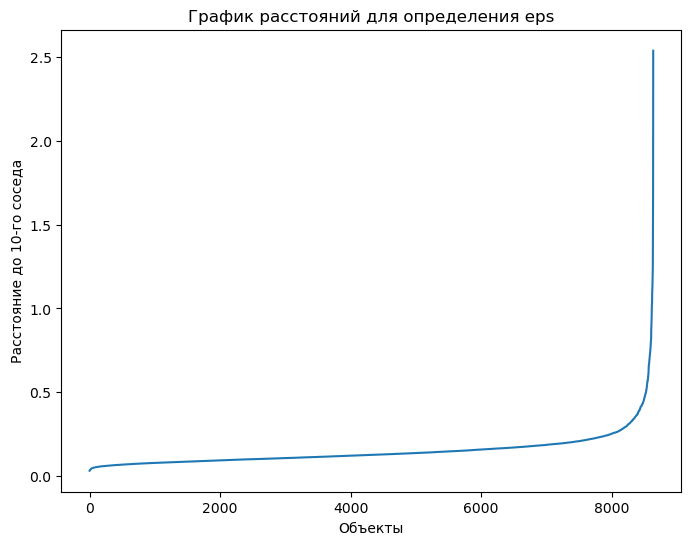

In [2]:
data_path = '../../../../data/processed_data/main_datasets/customer_data_processed.csv'
data = pd.read_csv(data_path)

X = data.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)

distances = np.sort(distances[:, -1])
plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.title('График расстояний для определения eps')
plt.xlabel('Объекты')
plt.ylabel('Расстояние до 10-го соседа')
plt.show()

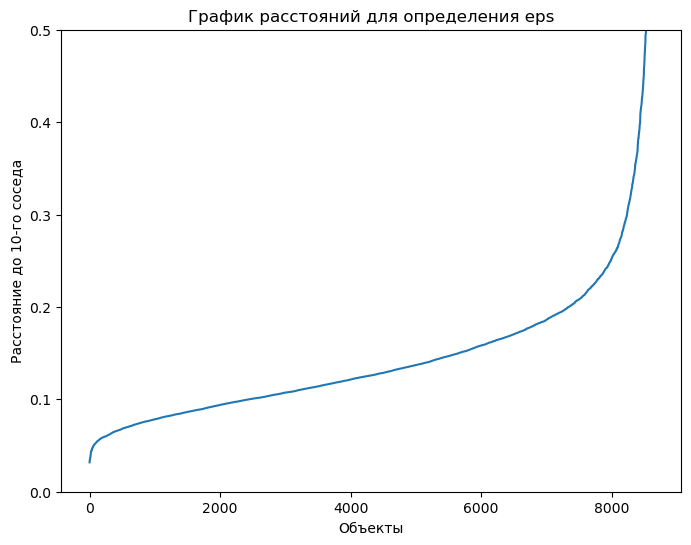

In [4]:
plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.ylim(0, 0.5) 
plt.title('График расстояний для определения eps')
plt.xlabel('Объекты')
plt.ylabel('Расстояние до 10-го соседа')
plt.show()

Как видим, значение eps можно принять равным 0.25

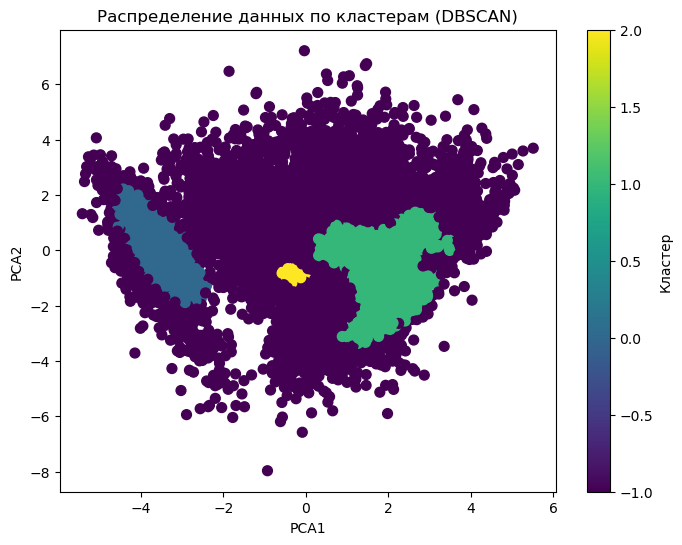

In [13]:
eps = 0.25
min_samples = 50

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan.fit(X_pca)

data['Cluster'] = dbscan.labels_

data['PCA1'] = X_pca[:, 0]
data['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(data['PCA1'], data['PCA2'], c=data['Cluster'], cmap='viridis', s=50)
plt.title('Распределение данных по кластерам (DBSCAN)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.colorbar(label='Кластер')
plt.show()

Как видим, DBSCAN не подходит для данной задачи

In [14]:
output_path = '../../../../data/processed_data/train_models_data/data_with_PCA/data_without_generated_features/DBSCAN_PCA.csv'
data.to_csv(output_path, index=False)